In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from prophet import Prophet
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import IsolationForest

# **Task 1 -  Data Loading, Merging & Deep Exploration**

In [2]:
# load the dataset
df_original = pd.read_csv('train.csv')

In [3]:
df_model = df_original.copy()

In [4]:
# top 10 rows of the dataset
df_model.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [5]:
print("No. of rows: ", df_model.shape[0])
print("No. of columns: ", df_model.shape[1])

No. of rows:  9800
No. of columns:  18


In [6]:
# Parse the Order Date and Ship Date columns as proper datetime objects
df_model['Order Date'] = pd.to_datetime(df_model['Order Date'], format= "%d/%m/%Y")
df_model['Ship Date'] = pd.to_datetime(df_model['Ship Date'], format= "%d/%m/%Y")

In [7]:
df_model.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
8335,8336,CA-2018-161655,2018-05-13,2018-05-18,Second Class,CW-11905,Carl Weiss,Home Office,United States,Newark,Delaware,19711.0,East,OFF-BI-10002082,Office Supplies,Binders,GBC Twin Loop Wire Binding Elements,299.520
9264,9265,US-2018-128118,2018-11-24,2018-12-01,Standard Class,MY-17380,Maribeth Yedwab,Corporate,United States,Memphis,Tennessee,38109.0,South,OFF-BI-10000216,Office Supplies,Binders,"Mead 1st Gear 2"" Zipper Binder, Asst. Colors",11.673
8363,8364,CA-2018-147207,2018-01-02,2018-01-04,Second Class,TS-21655,Trudy Schmidt,Consumer,United States,El Paso,Texas,79907.0,Central,OFF-ST-10002615,Office Supplies,Storage,"Dual Level, Single-Width Filing Carts",372.144
6710,6711,CA-2017-149503,2017-12-09,2017-12-12,First Class,SP-20650,Stephanie Phelps,Corporate,United States,Stockton,California,95207.0,West,OFF-BI-10002133,Office Supplies,Binders,"Wilson Jones Elliptical Ring 3 1/2"" Capacity B...",273.920
4441,4442,US-2017-111290,2017-07-22,2017-07-26,Standard Class,DK-13375,Dennis Kane,Consumer,United States,Westland,Michigan,48185.0,Central,OFF-ST-10001932,Office Supplies,Storage,Fellowes Staxonsteel Drawer Files,965.850


In [8]:
#  Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
df_model['Year'] = df_model['Order Date'].dt.year
df_model['Month'] = df_model['Order Date'].dt.month
df_model['Week Number'] = df_model['Order Date'].dt.isocalendar().week
df_model['Day of Week'] = df_model['Order Date'].dt.weekday
df_model['Quarter'] = df_model['Order Date'].dt.quarter

In [9]:
df_model['Season'] = df_model['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else ('Spring' if x in [3, 4, 5] else ('Summer' if x in [6, 7, 8] else 'Autumn')))

Seasons were derived using Northern Hemisphere months because the Superstore dataset represents a US-based retail business.

In [10]:
df_model.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,2,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,2,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,0,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,1,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,1,4,Autumn


In [11]:
# Check for missing values, duplicates, and data type issues
df_model.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


There are no such missing values in the columns except the postal code column

In [12]:
df_model.duplicated().sum()

np.int64(0)

There are no duplicate values present in the dataset

In [13]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

The postal code after filling the missing values can be changed to int datatype to reduce memory footprint a little

In [14]:
# Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)
monthly_sales= df_model.groupby('Month')['Sales'].sum()

In [15]:
print(type(monthly_sales))

<class 'pandas.core.series.Series'>


In [16]:
monthly_sales

,Sales
Month,
1,94291.6296
2,59371.1154
3,197573.5872
4,136283.0006
5,154086.7237
6,145837.5233
7,145535.6890
8,157315.9270
9,300103.4117


Monthly sales fluctuate significantly throughout the year, suggesting possible seasonal buying behaviour.

In [17]:
# df_model[df_model['Month'] == 9]['Sales'].sum()

In [18]:
weekly_sales = df_model.groupby(df_model['Week Number'])['Sales'].sum()

In [19]:
# df_model[df_model['Week Number'] == 1]['Sales'].sum()

In [20]:
weekly_sales

,Sales
Week Number,
1,17108.5440
2,15846.4320
3,21415.2770
4,25545.1980
5,29480.1000
6,12271.7710
7,16115.7144
8,9216.2930
9,28939.5784


# **○ Which product category generates the highest total revenue?**

If we are only talking about Categories(Furniture, Office Supplies, Technology) then **"Technology"** is the category with highest total revenue generated.

And, if we looking for sub-categories then the highest revenue generated sub-category is **"Phones"**.

In [21]:
# check for the unique categories and sub categories
df_model['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [22]:
df_model['Sub-Category'].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

In [23]:
df_model.groupby('Category')['Sales'].sum().sort_values(ascending = False).iloc[[0]]

,Sales
Category,
Technology,827455.873


In [24]:
df_model.groupby('Sub-Category')['Sales'].sum().sort_values(ascending = False).iloc[[0]]

,Sales
Sub-Category,
Phones,327782.448


# **○ Which region has the most consistent sales growth over 4 years?**

The most consistent region over 4 years is the **"West Region"**. As in the years 2015, 2017, and 2018 in west region the most sales are occured.

In [25]:
df_region_sales = pd.DataFrame(df_model.groupby(['Year', 'Region'])['Sales'].sum())

In [26]:
df_region_sales.groupby('Year')['Sales'].idxmax()

,Sales
Year,
2015,"(2015, West)"
2016,"(2016, East)"
2017,"(2017, West)"
2018,"(2018, West)"


# **○ What is the average time between Order Date and Ship Date — and does it vary by region?**

The average time between order date and ship date is **"3 days"**.

The average days per region is:

In **central** region it took **"4 days"**.

In **east** region it took **"3 days"**.

In **south** region it took **"3 days"**.

In **west** region it took **"3 days"**.

In [27]:
avg_days = (df_model['Ship Date'] - df_model['Order Date']).mean()

In [28]:
avg_days.days

3

In [29]:
df_m_g = df_model.groupby('Region')[['Ship Date', 'Order Date']]

In [30]:
shipping_time = df_m_g.apply(lambda x: (x['Ship Date'] - x['Order Date']).mean())

In [31]:
shipping_time.dt.days

,0
Region,
Central,4
East,3
South,3
West,3


# **○ Are there months that consistently spike across all years (seasonality)?**

The month with the highest sales varies slightly across years. September recorded the highest sales in 2015, November in 2016 and 2018, and December in 2017. Therefore, no single month consistently dominates every year. However, the sales peaks generally occur during the later months of the year (September–December), indicating an end-of-year seasonal increase in sales.

In [32]:
df_year_sales = pd.DataFrame(df_model.groupby(['Year', 'Month'])['Sales'].sum(), index = df_model.groupby(['Year', 'Month'])['Sales'].sum().index)

In [33]:
df_year_sales

Sales
Year Month             
2015 1       14205.7070
     2        4519.8920
     3       55205.7970
     4       27906.8550
     5       23644.3030
     6       34322.9356
     7       33781.5430
     8       27117.5365
     9       81623.5268
     10      31453.3930
     11      77907.6607
     12      68167.0585
2016 1       18066.9576
     2       11951.4110
     3       32339.3184
     4       34154.4685
     5       29959.5305
     6       23599.3740
     7       28608.2590
     8       36818.3422
     9       63133.6060
     10      31011.7375
     11      75249.3995
     12      74543.6012
2017 1       18542.4910
     2       22978.8150
     3       51165.0590
     4       38679.7670
     5       56656.9080
     6       39724.4860
     7       38320.7830
     8       30542.2003
     9       69193.3909
     10      59583.0330
     11      79066.4958
     12      95739.1210
2018 1       43476.4740
     2       19920.9974
     3       58863.4128
     4       35541.9101
     5       43825.9822
     6       48190.7277
     7       44825.1040
     8       62837.8480
     9       86152.8880
     10      77448.1312
     11     117938.1550
     12      83030.3888

In [34]:
df_year_sales.groupby('Year')['Sales'].idxmax()

,Sales
Year,
2015,"(2015, 9)"
2016,"(2016, 11)"
2017,"(2017, 12)"
2018,"(2018, 11)"


# **Task 2 — Time Series Analysis & Decomposition**

<Axes: xlabel='Month', ylabel='Sales'>

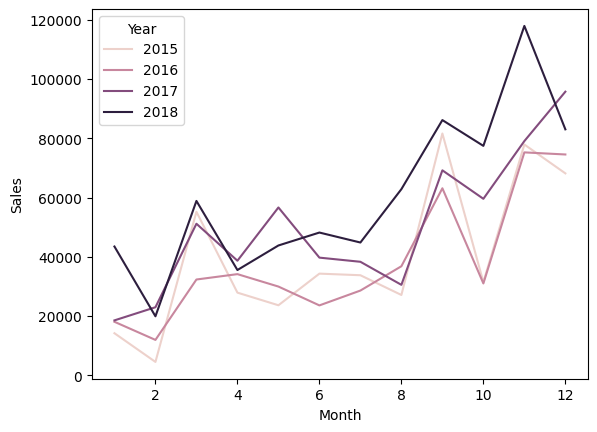

In [35]:
# Plot the overall monthly sales trend across all 4 years
sns.lineplot(data = df_year_sales, x = 'Month', y = 'Sales', hue = 'Year')

In [36]:
monthly_sales = df_model.set_index('Order Date').resample('ME')['Sales'].sum()

In [37]:
# Apply Time Series Decomposition (using statsmodels) to break the sales signal
# into:
# ○ Trend component
# ○ Seasonal component
# ○ Residual/noise component

from statsmodels.tsa.seasonal import seasonal_decompose

sd = seasonal_decompose(monthly_sales, period = 12, model = 'additive')

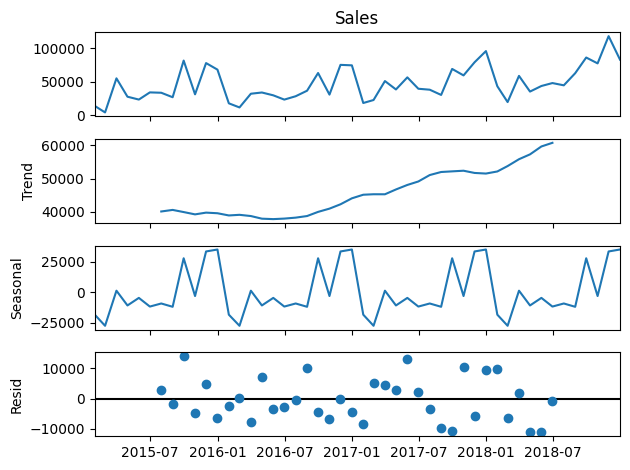

In [38]:
sd.plot()
plt.show()

# **Write 3–4 observations: what does the trend tell you?**

Observation 1:

The trend component indicates an overall increase in sales from mid-2016 onwards, suggesting sustained business growth over the analyzed period.

Observation 2:

The seasonal component exhibits a repeating yearly pattern, indicating that sales are influenced by recurring seasonal effects rather than random fluctuations alone.

Observation 3:

The residual component contains both positive and negative deviations, indicating that certain months experienced sales significantly above or below the values explained by trend and seasonality.

Observation 4:

Overall, the decomposition suggests that monthly sales are influenced by a combination of long-term growth, recurring seasonal demand, and occasional irregular events.

#**Is seasonality strong or weak?**
I would classify it as

Moderate to strong seasonality.

Why?

Because:

the seasonal pattern repeats,
the peaks and troughs are clear,
and the amplitude is substantial.

# **What months show the highest residual noise?**

# **Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you**

In [39]:
adf_statistic, p_value, used_lags, n_obs, critical_values, icbest = adfuller(monthly_sales)

In [40]:
print(f"ADF Statistic      : {adf_statistic:.4f}")
print(f"P-value            : {p_value:.6f}")
print(f"Used Lags          : {used_lags}")
print(f"Number of Observations : {n_obs}")

print("\nCritical Values:")
for key, value in critical_values.items():
    print(f"{key}: {value:.4f}")

ADF Statistic      : -4.4161
P-value            : 0.000278
Used Lags          : 0
Number of Observations : 47

Critical Values:
1%: -3.5778
5%: -2.9253
10%: -2.6008


**Stationarity** means that the statistical properties of a time series, such as its average (mean) and variability (variance), remain relatively stable over time. A stationary time series does not exhibit a continuously increasing or decreasing trend, making it more suitable for forecasting models like ARIMA and SARIMA.

**ADF Test Result -**
The Augmented Dickey-Fuller (ADF) test was performed on the monthly sales time series to check whether it is stationary. The test produced an ADF statistic of -4.4161 with a p-value of 0.000278, which is less than the significance level of 0.05. Therefore, the null hypothesis of the presence of a unit root is rejected, indicating that the monthly sales series is stationary. Since the series is already stationary, no differencing is required before applying forecasting models.

# **Apply differencing if the series is non-stationary and re-test**

Since the ADF test confirms that the monthly sales series is stationary (p-value < 0.05), differencing was not applied, as it is only required for non-stationary time series. The original series can be used directly for forecasting.

# **Task 3 — Sales Forecasting using 3 Different Models**

**Model 1 — SARIMA (Statistical Model)**

In [41]:
sm1 = SARIMAX(monthly_sales, order = (1, 0, 0), seasonal_order = (1, 1, 1, 12))

In [42]:
sarima_fit1 = sm1.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [43]:
sarima_fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 0)x(1, 1, [1], 12)   Log Likelihood                -395.472
Date:                              Sun, 12 Jul 2026   AIC                            798.945
Time:                                      17:18:03   BIC                            805.279
Sample:                                  01-31-2015   HQIC                           801.156
                                       - 12-31-2018                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2956      0.142      2.082      0.037       0.017       0.574
ar.S.L12      -0.2960      0.748     -0.396      0.692      -1.763       1.171
ma.S.L12       0.1149      0.765      0.150      0.881      -1.384       1.613
sigma2      2.228e+08   1.53e-09   1.45e+17      0.000    2.23e+08    2.23e+08
===================================================================================
Ljung-Box (L1) (Q):                   2.26   Jarque-Bera (JB):                 0.60
Prob(Q):                              0.13   Prob(JB):                         0.74
Heteroskedasticity (H):               2.51   Skew:                             0.04
Prob(H) (two-sided):                  0.12   Kurtosis:                         2.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.59e+34. Standard errors may be unstable.
"""

In [44]:
sm2 = SARIMAX(monthly_sales, order = (1, 0, 1), seasonal_order = (1, 1, 1, 12))

In [45]:
sarima_fit2 = sm2.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [46]:
sarima_fit2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -388.556
Date:                            Sun, 12 Jul 2026   AIC                            787.113
Time:                                    17:18:03   BIC                            795.030
Sample:                                01-31-2015   HQIC                           789.876
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9998      0.020     51.092      0.000       0.961       1.038
ma.L1         -0.9953      0.273     -3.647      0.000      -1.530      -0.460
ar.S.L12      -0.1702      0.470     -0.362      0.717      -1.092       0.751
ma.S.L12      -0.2056      0.530     -0.388      0.698      -1.244       0.833
sigma2       1.83e+08   7.55e-10   2.42e+17      0.000    1.83e+08    1.83e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.52
Prob(Q):                              0.92   Prob(JB):                         0.47
Heteroskedasticity (H):               2.43   Skew:                             0.38
Prob(H) (two-sided):                  0.14   Kurtosis:                         2.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.35e+34. Standard errors may be unstable.
"""

Hence, this model has the lowest AIC value, so we will use this model for predictions

In [47]:
sm3 = SARIMAX(monthly_sales, order = (2, 0, 1), seasonal_order = (1, 1, 1, 12))

In [48]:
sm3_fit = sm3.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [49]:
sm3_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(2, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -388.549
Date:                            Sun, 12 Jul 2026   AIC                            789.098
Time:                                    17:18:04   BIC                            798.599
Sample:                                01-31-2015   HQIC                           792.414
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9834      0.244      4.024      0.000       0.504       1.462
ar.L2          0.0164      0.252      0.065      0.948      -0.477       0.510
ma.L1         -0.9952      0.284     -3.509      0.000      -1.551      -0.439
ar.S.L12      -0.1743      0.477     -0.365      0.715      -1.110       0.761
ma.S.L12      -0.1990      0.536     -0.372      0.710      -1.249       0.851
sigma2       1.83e+08   7.69e-10   2.38e+17      0.000    1.83e+08    1.83e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 1.51
Prob(Q):                              0.86   Prob(JB):                         0.47
Heteroskedasticity (H):               2.44   Skew:                             0.38
Prob(H) (two-sided):                  0.14   Kurtosis:                         2.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.81e+33. Standard errors may be unstable.
"""

In [50]:
# sample prediction
pred = sarima_fit2.predict(
    start=monthly_sales.index[0],
    end=monthly_sales.index[-1]
)

In [51]:
pred

,predicted_mean
Order Date,
2015-01-31,0.000000
2015-02-28,359.943169
2015-03-31,462.593325
2015-04-30,1782.634507
2015-05-31,2397.119019
2015-06-30,2885.014753
2015-07-31,3590.993346
2015-08-31,4253.754594
2015-09-30,4744.269656


# **Generate a 3-month future forecast with confidence intervals**

In [52]:
forecast = sarima_fit2.get_forecast(steps=3)

forecast_values = forecast.predicted_mean
confidence_interval = forecast.conf_int()

In [53]:
forecast_values

,predicted_mean
2019-01-31,48057.301533
2019-02-28,34177.154904
2019-03-31,68799.304842


In [54]:
confidence_interval

,lower Sales,upper Sales
2019-01-31,21352.951140,74761.651926
2019-02-28,7472.601304,60881.708504
2019-03-31,42094.548106,95504.061579


# **Plot actual vs forecasted sales**

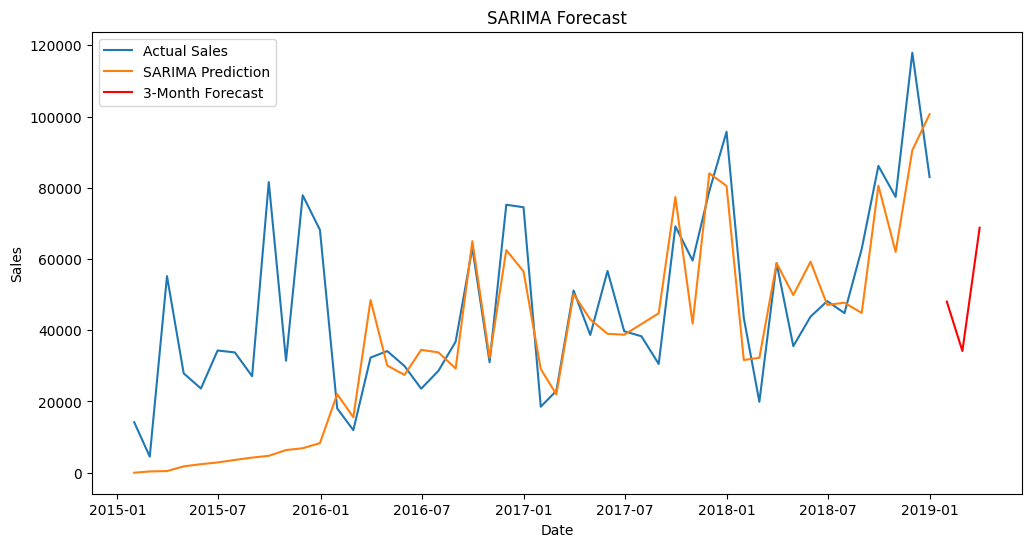

In [55]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales, label='Actual Sales')
plt.plot(pred, label='SARIMA Prediction')
plt.plot(forecast_values, label='3-Month Forecast', color='red')

plt.legend()
plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# **Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them?**

**Choice of SARIMA Parameters**

**The SARIMA model was configured with:**

(p, d, q) = (1, 0, 1)
(P, D, Q, m) = (1, 1, 1, 12)
Reason for choosing (p, d, q) = (1, 0, 1)
p = 1: One autoregressive (AR) term was included so that the model can use information from the previous month's sales to predict the current month's sales.


d = 0: The Augmented Dickey-Fuller (ADF) test confirmed that the monthly sales series is already stationary (p-value = 0.000278 < 0.05). Therefore, regular differencing was not required.


q = 1: One moving average (MA) term was included to model the effect of previous forecast errors and improve the model's ability to capture short-term fluctuations.


**Reason for choosing (P, D, Q, m) = (1, 1, 1, 12)**

P = 1: Includes one seasonal autoregressive component to capture relationships between sales in the same season across different years.

D = 1: Seasonal differencing was included to remove yearly seasonal effects and improve the model's ability to model recurring seasonal patterns.

Q = 1: Includes one seasonal moving average component to account for seasonal forecast errors.

m = 12: Since the data was aggregated into monthly sales, one complete seasonal cycle consists of 12 months, making m = 12 appropriate.

The parameter values were selected based on the characteristics of the monthly sales data. The ADF test indicated that the series was already stationary, so no regular differencing was required (d = 0). The decomposition plot revealed a recurring yearly seasonal pattern, so a seasonal period of 12 months was used. Simple AR and MA terms were included to capture both short-term and seasonal dependencies while keeping the model relatively simple for this forecasting task.

**Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)**

In [56]:
# Install Prophet
!pip install prophet

In [57]:
# Prepare data in Prophet's required format (ds, y columns)
pm = Prophet()

In [58]:
df_p_m = monthly_sales.reset_index()
df_p_m.columns = ['ds', 'y']

In [59]:
df_p_m.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [60]:
df_p_m.shape

(48, 2)

In [61]:
df_p_m['y'].describe()

,y
count,48.000000
mean,47115.349640
std,24978.687305
min,4519.892000
25%,29621.712625
50%,39202.126500
75%,64391.969125
max,117938.155000


In [62]:
pm.fit(df_p_m)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [63]:
future = pm.make_future_dataframe(periods=6, freq = 'ME')
future.tail()

,ds
49,2019-02-28
50,2019-03-31
51,2019-04-30
52,2019-05-31
53,2019-06-30


In [64]:
forecast = pm.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
49,2019-02-28,31248.159925,21840.077834,40056.294898
50,2019-03-31,81267.007775,72165.004755,90025.779215
51,2019-04-30,50658.420144,41330.715637,59843.612681
52,2019-05-31,52555.922390,43542.429391,60995.053328
53,2019-06-30,60032.020402,49587.777056,69269.055462


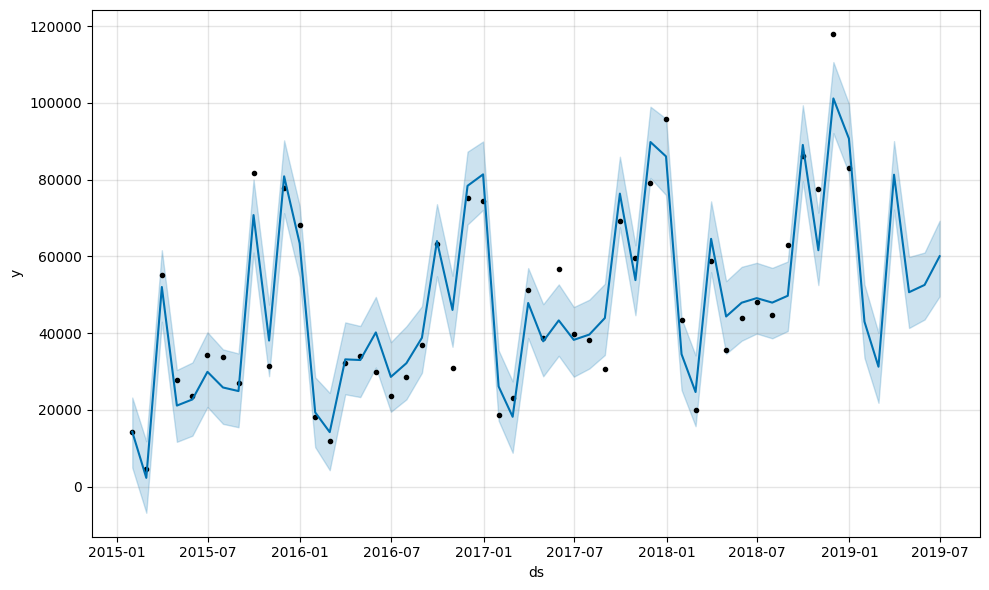

In [65]:
fig1 = pm.plot(forecast)

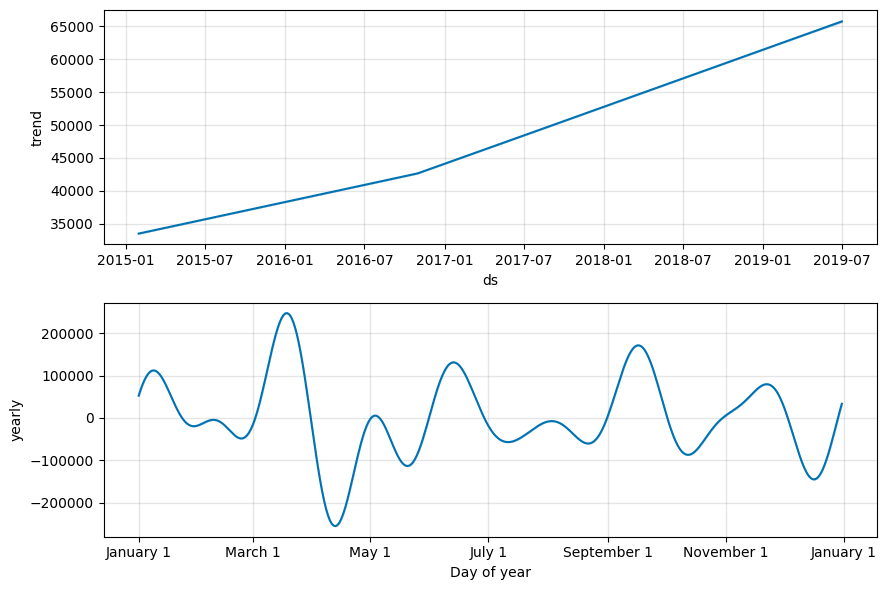

In [66]:
fig2 = pm.plot_components(forecast)

**Model 3 — XGBoost for Time Series (ML-based Approach)**

In [67]:
ts_df = monthly_sales.reset_index()
ts_df.columns = ['Date', 'Sales']

In [68]:
ts_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [69]:
ts_df['Lag_1'] = ts_df['Sales'].shift(1)
ts_df['Lag_2'] = ts_df['Sales'].shift(2)
ts_df['Lag_3'] = ts_df['Sales'].shift(3)

In [70]:
ts_df['Rolling_Mean_3'] = (
    ts_df['Sales']
    .rolling(window=3)
    .mean()
)

In [71]:
ts_df['Month'] = ts_df['Date'].dt.month
ts_df['Quarter'] = ts_df['Date'].dt.quarter

In [72]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

ts_df['Season'] = ts_df['Month'].apply(get_season)

In [73]:
ts_df = pd.get_dummies(
    ts_df,
    columns=['Season'],
    drop_first=True
)

In [74]:
ts_df = ts_df.dropna()

In [75]:
X = ts_df.drop(columns=['Date', 'Sales'])

y = ts_df['Sales']

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = False)

In [78]:
xgb_m = xgb.XGBRegressor()

In [79]:
xgb_m.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [80]:
pred = xgb_m.predict(X_test)

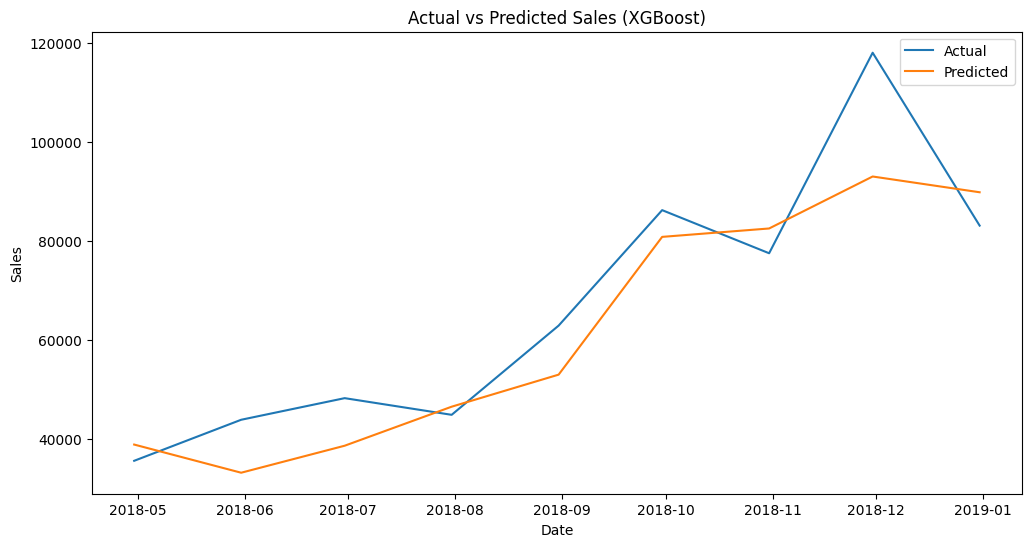

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    ts_df['Date'].loc[y_test.index],
    y_test,
    label='Actual'
)

plt.plot(
    ts_df['Date'].loc[y_test.index],
    pred,
    label='Predicted'
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales (XGBoost)")
plt.legend()

plt.show()

In [82]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))
print("R2 :", r2_score(y_test, pred))

MAE : 8582.529557638889
RMSE : 10760.89368269127
R2 : 0.8176748849319958


# **Model Comparison Table**

Sarima Predictions

In [83]:
# Number of observations in XGBoost test set
test_size = len(y_test)

# Same actual monthly sales for comparison
actual_test = monthly_sales.iloc[-test_size:]

print("Test observations:", test_size)
print("Test period:", actual_test.index[0], "to", actual_test.index[-1])

Test observations: 9
Test period: 2018-04-30 00:00:00 to 2018-12-31 00:00:00


In [84]:
sarima_train = monthly_sales.iloc[:-test_size]

In [85]:
sarima_compare = SARIMAX(
    sarima_train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12)
)

sarima_compare_fit = sarima_compare.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [86]:
sarima_test_pred = sarima_compare_fit.forecast(steps=test_size)

In [87]:
sarima_test_pred.index = actual_test.index

Prophet Predictions

In [88]:
prophet_train = monthly_sales.iloc[:-test_size].reset_index()
prophet_train.columns = ['ds', 'y']

In [89]:
prophet_compare = Prophet()

prophet_compare.fit(prophet_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [90]:
prophet_future = pd.DataFrame({
    'ds': actual_test.index
})

In [91]:
prophet_test_forecast = prophet_compare.predict(prophet_future)

In [92]:
prophet_test_pred = prophet_test_forecast['yhat'].values

Xg Boost predictions

In [93]:
xgb_test_pred = pred

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

In [95]:
print(len(actual_test))
print(len(sarima_test_pred))
print(len(prophet_test_pred))
print(len(xgb_test_pred))

9
9
9
9


Calculating metrics for all three models

In [96]:
def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = mean_absolute_percentage_error(
        actual, predicted
    ) * 100

    return mae, rmse, mape

In [97]:
sarima_mae, sarima_rmse, sarima_mape = calculate_metrics(
    actual_test,
    sarima_test_pred
)

prophet_mae, prophet_rmse, prophet_mape = calculate_metrics(
    actual_test,
    prophet_test_pred
)

xgb_mae, xgb_rmse, xgb_mape = calculate_metrics(
    y_test,
    xgb_test_pred
)

In [98]:
model_comparison = pd.DataFrame({

    'Model': [
        'SARIMA',
        'Prophet',
        'XGBoost'
    ],

    'MAE': [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    'RMSE': [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    'MAPE (%)': [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ]
})

model_comparison = model_comparison.round(2)

model_comparison

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,16945.65,20108.86,24.39
1,Prophet,10755.35,15469.55,14.99
2,XGBoost,8582.53,10760.89,12.78


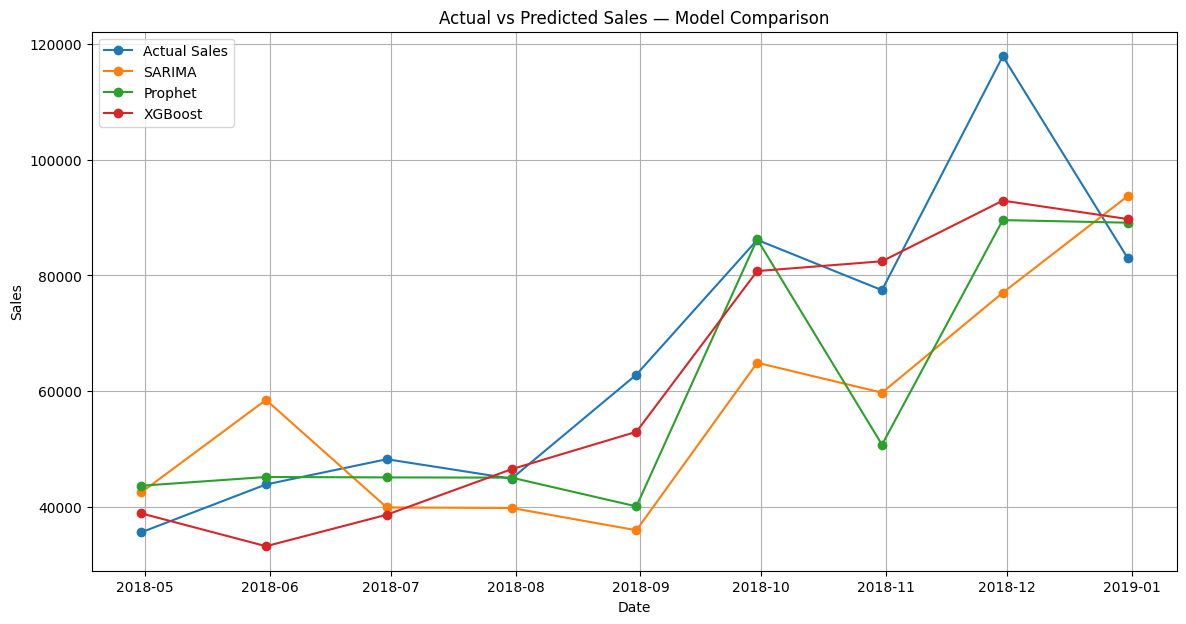

In [99]:
plt.figure(figsize=(14, 7))

plt.plot(
    actual_test.index,
    actual_test.values,
    marker='o',
    label='Actual Sales'
)

plt.plot(
    actual_test.index,
    sarima_test_pred.values,
    marker='o',
    label='SARIMA'
)

plt.plot(
    actual_test.index,
    prophet_test_pred,
    marker='o',
    label='Prophet'
)

plt.plot(
    actual_test.index,
    xgb_test_pred,
    marker='o',
    label='XGBoost'
)

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Actual vs Predicted Sales — Model Comparison')
plt.legend()
plt.grid(True)

plt.show()

Model Comparison Conclusion: Among the three forecasting models evaluated on the same test period, XGBoost achieved the best overall forecasting performance, with the lowest MAE of 8,582.53, RMSE of 10,760.89, and MAPE of 12.78%. Prophet ranked second with a MAPE of 14.99%, while SARIMA produced the highest forecasting error with a MAPE of 24.39%. Therefore, XGBoost was selected as the best-performing model for this dataset. Its superior performance suggests that the engineered lag features, 3-month rolling average, and calendar-based features successfully captured useful temporal patterns in monthly sales.

# **Task 4 — Product Category & Region Level Forecasting**

In [100]:
import pandas as pd
import numpy as np
import xgboost as xgb


def xgboost_segment_forecast(segment_df, periods=3):

    # ------------------------------------------------
    # 1. Create monthly sales time series
    # ------------------------------------------------

    monthly = (
        segment_df
        .set_index('Order Date')
        .resample('ME')['Sales']
        .sum()
        .reset_index()
    )

    monthly.columns = ['Date', 'Sales']


    # ------------------------------------------------
    # 2. Create lag features
    # ------------------------------------------------

    monthly['Lag_1'] = monthly['Sales'].shift(1)
    monthly['Lag_2'] = monthly['Sales'].shift(2)
    monthly['Lag_3'] = monthly['Sales'].shift(3)


    # ------------------------------------------------
    # 3. Create 3-month rolling mean
    # Use shift(1) to prevent target leakage
    # ------------------------------------------------

    monthly['Rolling_Mean_3'] = (
        monthly['Sales']
        .shift(1)
        .rolling(window=3)
        .mean()
    )


    # ------------------------------------------------
    # 4. Calendar features
    # ------------------------------------------------

    monthly['Month'] = monthly['Date'].dt.month
    monthly['Quarter'] = monthly['Date'].dt.quarter


    # ------------------------------------------------
    # 5. Season feature
    # ------------------------------------------------

    def get_season(month):

        if month in [12, 1, 2]:
            return 'Winter'

        elif month in [3, 4, 5]:
            return 'Spring'

        elif month in [6, 7, 8]:
            return 'Summer'

        else:
            return 'Autumn'


    monthly['Season'] = monthly['Month'].apply(get_season)


    # ------------------------------------------------
    # 6. One-hot encode Season
    # ------------------------------------------------

    monthly = pd.get_dummies(
        monthly,
        columns=['Season'],
        dtype=int
    )


    # ------------------------------------------------
    # 7. Remove NaN rows caused by lag features
    # ------------------------------------------------

    model_data = monthly.dropna().copy()


    # ------------------------------------------------
    # 8. Define X and y
    # ------------------------------------------------

    X = model_data.drop(
        columns=['Date', 'Sales']
    )

    y = model_data['Sales']


    # ------------------------------------------------
    # 9. Train XGBoost
    # ------------------------------------------------

    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)


    # ------------------------------------------------
    # 10. Prepare recursive forecasting
    # ------------------------------------------------

    sales_history = monthly['Sales'].tolist()

    last_date = monthly['Date'].iloc[-1]

    future_predictions = []


    # ------------------------------------------------
    # 11. Forecast next 3 months recursively
    # ------------------------------------------------

    for i in range(periods):

        next_date = last_date + pd.DateOffset(months=1)

        month = next_date.month
        quarter = next_date.quarter


        # Determine season

        if month in [12, 1, 2]:
            season = 'Winter'

        elif month in [3, 4, 5]:
            season = 'Spring'

        elif month in [6, 7, 8]:
            season = 'Summer'

        else:
            season = 'Autumn'


        # Latest sales become lag features

        lag_1 = sales_history[-1]
        lag_2 = sales_history[-2]
        lag_3 = sales_history[-3]

        rolling_mean_3 = np.mean(
            sales_history[-3:]
        )


        # Create one future observation

        future_row = pd.DataFrame({

            'Lag_1': [lag_1],
            'Lag_2': [lag_2],
            'Lag_3': [lag_3],

            'Rolling_Mean_3': [rolling_mean_3],

            'Month': [month],
            'Quarter': [quarter]
        })


        # Add season columns

        for season_name in [
            'Autumn',
            'Spring',
            'Summer',
            'Winter'
        ]:

            column_name = f'Season_{season_name}'

            future_row[column_name] = int(
                season == season_name
            )


        # Ensure exact same columns as training data

        future_row = future_row.reindex(
            columns=X.columns,
            fill_value=0
        )


        # Predict

        prediction = model.predict(future_row)[0]


        # Save prediction

        future_predictions.append({

            'Date': next_date,
            'Predicted_Sales': prediction

        })


        # Add prediction to history for next recursive step

        sales_history.append(prediction)

        last_date = next_date


    # Convert predictions into DataFrame

    forecast_df = pd.DataFrame(
        future_predictions
    )


    return forecast_df, model

In [101]:
# Category segments

furniture_df = df_model[
    df_model['Category'] == 'Furniture'
].copy()


technology_df = df_model[
    df_model['Category'] == 'Technology'
].copy()


office_supplies_df = df_model[
    df_model['Category'] == 'Office Supplies'
].copy()


# Region segments

west_df = df_model[
    df_model['Region'] == 'West'
].copy()


east_df = df_model[
    df_model['Region'] == 'East'
].copy()

In [102]:
furniture_forecast, furniture_model = xgboost_segment_forecast(
    furniture_df,
    periods=3
)


technology_forecast, technology_model = xgboost_segment_forecast(
    technology_df,
    periods=3
)


office_forecast, office_model = xgboost_segment_forecast(
    office_supplies_df,
    periods=3
)


west_forecast, west_model = xgboost_segment_forecast(
    west_df,
    periods=3
)


east_forecast, east_model = xgboost_segment_forecast(
    east_df,
    periods=3
)

In [103]:
print("Furniture Forecast")
display(furniture_forecast)

print("\nTechnology Forecast")
display(technology_forecast)

print("\nOffice Supplies Forecast")
display(office_forecast)

print("\nWest Region Forecast")
display(west_forecast)

print("\nEast Region Forecast")
display(east_forecast)

Furniture Forecast


,Date,Predicted_Sales
0,2019-01-31,6519.750000
1,2019-02-28,6657.141113
2,2019-03-28,12016.707031



Technology Forecast


,Date,Predicted_Sales
0,2019-01-31,15237.088867
1,2019-02-28,17034.441406
2,2019-03-28,20251.566406



Office Supplies Forecast


,Date,Predicted_Sales
0,2019-01-31,17114.929688
1,2019-02-28,11464.643555
2,2019-03-28,19536.355469



West Region Forecast


,Date,Predicted_Sales
0,2019-01-31,11097.477539
1,2019-02-28,10663.012695
2,2019-03-28,17832.117188



East Region Forecast


,Date,Predicted_Sales
0,2019-01-31,5032.635742
1,2019-02-28,5478.297852
2,2019-03-28,10939.249023


In [104]:
forecast_comparison = pd.DataFrame({

    'Date': furniture_forecast['Date'],

    'Furniture': furniture_forecast['Predicted_Sales'],

    'Technology': technology_forecast['Predicted_Sales'],

    'Office Supplies': office_forecast['Predicted_Sales'],

    'West Region': west_forecast['Predicted_Sales'],

    'East Region': east_forecast['Predicted_Sales']

})

forecast_comparison = forecast_comparison.round(2)

forecast_comparison

,Date,Furniture,Technology,Office Supplies,West Region,East Region
0,2019-01-31,6519.750000,15237.089844,17114.929688,11097.480469,5032.640137
1,2019-02-28,6657.140137,17034.439453,11464.639648,10663.009766,5478.299805
2,2019-03-28,12016.709961,20251.570312,19536.359375,17832.119141,10939.250000


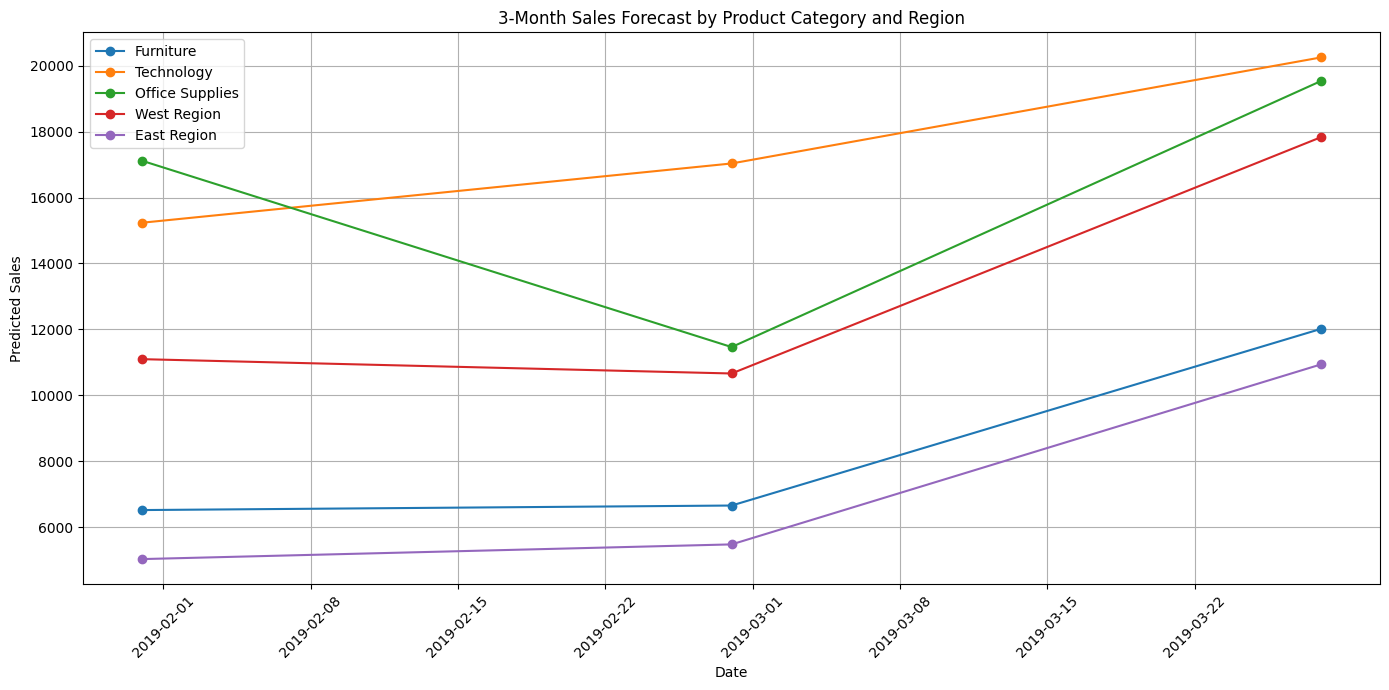

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))


plt.plot(
    furniture_forecast['Date'],
    furniture_forecast['Predicted_Sales'],
    marker='o',
    label='Furniture'
)


plt.plot(
    technology_forecast['Date'],
    technology_forecast['Predicted_Sales'],
    marker='o',
    label='Technology'
)


plt.plot(
    office_forecast['Date'],
    office_forecast['Predicted_Sales'],
    marker='o',
    label='Office Supplies'
)


plt.plot(
    west_forecast['Date'],
    west_forecast['Predicted_Sales'],
    marker='o',
    label='West Region'
)


plt.plot(
    east_forecast['Date'],
    east_forecast['Predicted_Sales'],
    marker='o',
    label='East Region'
)


plt.xlabel('Date')

plt.ylabel('Predicted Sales')

plt.title(
    '3-Month Sales Forecast by Product Category and Region'
)

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [106]:
growth_rates = {

    'Furniture':
        (
            furniture_forecast['Predicted_Sales'].iloc[-1]
            - furniture_forecast['Predicted_Sales'].iloc[0]
        )
        / furniture_forecast['Predicted_Sales'].iloc[0]
        * 100,


    'Technology':
        (
            technology_forecast['Predicted_Sales'].iloc[-1]
            - technology_forecast['Predicted_Sales'].iloc[0]
        )
        / technology_forecast['Predicted_Sales'].iloc[0]
        * 100,


    'Office Supplies':
        (
            office_forecast['Predicted_Sales'].iloc[-1]
            - office_forecast['Predicted_Sales'].iloc[0]
        )
        / office_forecast['Predicted_Sales'].iloc[0]
        * 100,


    'West Region':
        (
            west_forecast['Predicted_Sales'].iloc[-1]
            - west_forecast['Predicted_Sales'].iloc[0]
        )
        / west_forecast['Predicted_Sales'].iloc[0]
        * 100,


    'East Region':
        (
            east_forecast['Predicted_Sales'].iloc[-1]
            - east_forecast['Predicted_Sales'].iloc[0]
        )
        / east_forecast['Predicted_Sales'].iloc[0]
        * 100
}

In [107]:
growth_df = pd.DataFrame(
    growth_rates.items(),
    columns=['Segment', 'Forecast Growth (%)']
)

growth_df = growth_df.sort_values(
    by='Forecast Growth (%)',
    ascending=False
).reset_index(drop=True)

growth_df['Forecast Growth (%)'] = (
    growth_df['Forecast Growth (%)'].round(2)
)

growth_df

,Segment,Forecast Growth (%)
0,East Region,117.370003
1,Furniture,84.309998
2,West Region,60.689999
3,Technology,32.910000
4,Office Supplies,14.150000


In [108]:
strongest_segment = growth_df.iloc[0]['Segment']

strongest_growth = growth_df.iloc[0]['Forecast Growth (%)']


print(
    f"The segment showing the strongest upcoming growth is "
    f"{strongest_segment}, with forecasted growth of "
    f"{strongest_growth}% from Month 1 to Month 3."
)

The segment showing the strongest upcoming growth is East Region, with forecasted growth of 117.37000274658203% from Month 1 to Month 3.


# **Task 5 — Anomaly Detection in Sales Data**

In [109]:
# Aggregate daily/order-level sales into weekly sales

weekly_sales = (
    df_model
    .set_index('Order Date')
    .resample('W')['Sales']
    .sum()
)

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [110]:
weekly_df = weekly_sales.reset_index()

weekly_df.columns = ['Date', 'Sales']

weekly_df.head()

,Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [111]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_df['Isolation_Anomaly'] = iso_model.fit_predict(
    weekly_df[['Sales']]
)

In [112]:
iso_anomalies = weekly_df[
    weekly_df['Isolation_Anomaly'] == -1
]

iso_anomalies

,Date,Sales,Isolation_Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


In [113]:
print(
    "Number of anomalies detected by Isolation Forest:",
    len(iso_anomalies)
)

Number of anomalies detected by Isolation Forest: 11


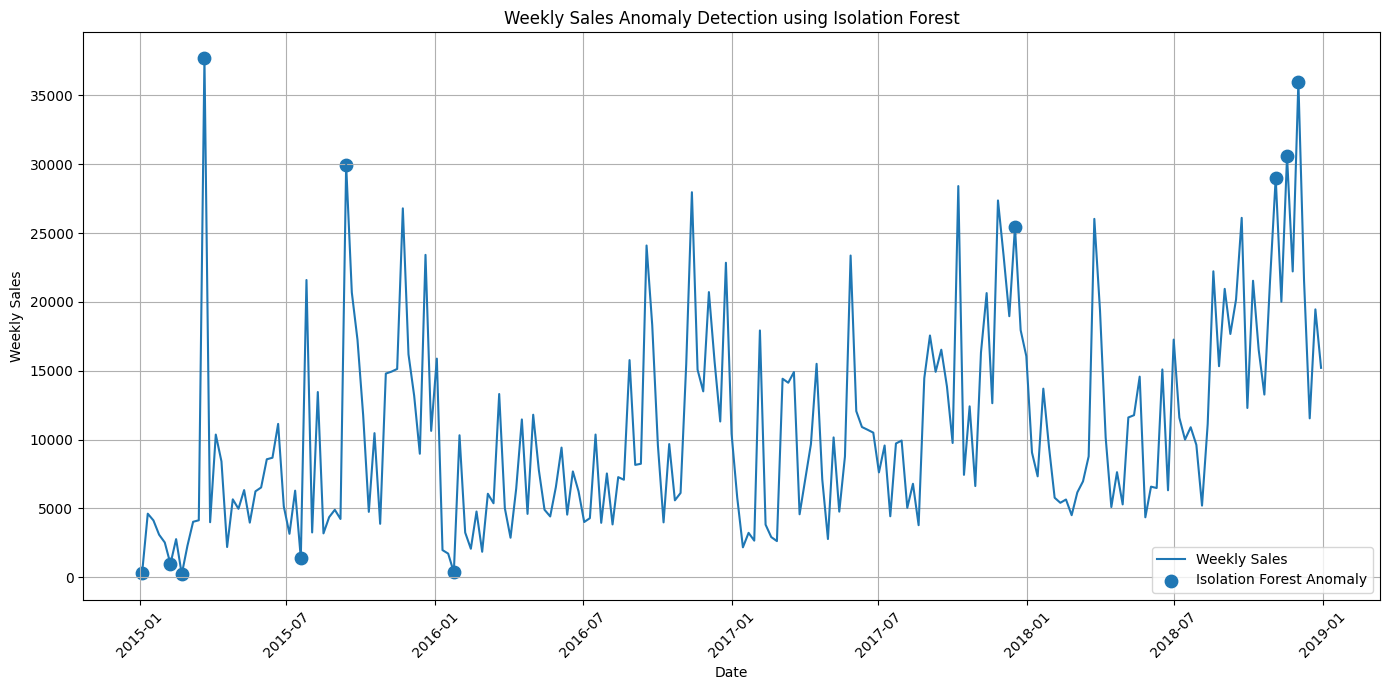

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Plot complete weekly sales series
plt.plot(
    weekly_df['Date'],
    weekly_df['Sales'],
    label='Weekly Sales'
)

# Plot anomalies
plt.scatter(
    iso_anomalies['Date'],
    iso_anomalies['Sales'],
    label='Isolation Forest Anomaly',
    marker='o',
    s=80
)

plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Weekly Sales Anomaly Detection using Isolation Forest')

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [116]:
weekly_df['Rolling_Mean'] = (
    weekly_df['Sales']
    .rolling(window=4)
    .mean()
)

In [117]:
def explain_anomaly(row):

    month = row['Date'].month

    if row['Anomaly_Type'] == 'Unusual High Sales':

        if month in [10, 11, 12]:
            return (
                'Possible festive or holiday-season demand, '
                'year-end promotions, or seasonal sales campaigns.'
            )

        else:
            return (
                'Possible promotional campaign, bulk order, '
                'temporary demand spike, or special event.'
            )

    else:

        return (
            'Possible seasonal slowdown, stock availability issue, '
            'reduced customer demand, or operational disruption.'
        )

# Calculate the mean of weekly sales to determine if an anomaly is high or low
mean_weekly_sales = weekly_df['Sales'].mean()

# Filter anomalies and create a true copy to avoid SettingWithCopyWarning
iso_anomalies = weekly_df[weekly_df['Isolation_Anomaly'] == -1].copy()

# Add 'Anomaly_Type' column to iso_anomalies
iso_anomalies.loc[:, 'Anomaly_Type'] = iso_anomalies.apply(
    lambda row: 'Unusual High Sales' if row['Sales'] > mean_weekly_sales else 'Unusual Low Sales',
    axis=1
)

iso_anomalies['Possible_Explanation'] = (
    iso_anomalies.apply(
        explain_anomaly,
        axis=1
    )
)


iso_anomalies[
    [
        'Date',
        'Sales',
        'Anomaly_Type',
        'Possible_Explanation'
    ]
]

,Date,Sales,Anomaly_Type,Possible_Explanation
0,2015-01-04,304.508,Unusual Low Sales,"Possible seasonal slowdown, stock availability..."
5,2015-02-08,968.534,Unusual Low Sales,"Possible seasonal slowdown, stock availability..."
7,2015-02-22,224.912,Unusual Low Sales,"Possible seasonal slowdown, stock availability..."
11,2015-03-22,37703.665,Unusual High Sales,"Possible promotional campaign, bulk order, tem..."
28,2015-07-19,1387.686,Unusual Low Sales,"Possible seasonal slowdown, stock availability..."
36,2015-09-13,29959.137,Unusual High Sales,"Possible promotional campaign, bulk order, tem..."
55,2016-01-24,358.522,Unusual Low Sales,"Possible seasonal slowdown, stock availability..."
154,2017-12-17,25449.800,Unusual High Sales,"Possible festive or holiday-season demand, yea..."
200,2018-11-04,29017.467,Unusual High Sales,"Possible festive or holiday-season demand, yea..."
202,2018-11-18,30572.447,Unusual High Sales,"Possible festive or holiday-season demand, yea..."


Note: The explanations presented for detected anomalies represent plausible business hypotheses based on the timing and direction of sales deviations. Without additional information about promotions, inventory levels, holidays, or operational events, the exact cause of each anomaly cannot be confirmed from the sales dataset alone.

In [118]:
weekly_df['Rolling_Mean_Z'] = (
    weekly_df['Sales']
    .shift(1)
    .rolling(window=4)
    .mean()
)


weekly_df['Rolling_Std_Z'] = (
    weekly_df['Sales']
    .shift(1)
    .rolling(window=4)
    .std()
)

In [119]:
weekly_df['Z_Score'] = (
    (
        weekly_df['Sales']
        - weekly_df['Rolling_Mean_Z']
    )
    / weekly_df['Rolling_Std_Z']
)

In [120]:
weekly_df['Z_Anomaly'] = (
    weekly_df['Z_Score'].abs() > 2
)

In [121]:
z_anomalies = weekly_df[
    weekly_df['Z_Anomaly'] == True
].copy()

z_anomalies[
    [
        'Date',
        'Sales',
        'Rolling_Mean_Z',
        'Rolling_Std_Z',
        'Z_Score'
    ]
]

,Date,Sales,Rolling_Mean_Z,Rolling_Std_Z,Z_Score
5,2015-02-08,968.5340,3592.524750,953.362968,-2.752352
7,2015-02-22,224.9120,2340.011500,943.108457,-2.242690
9,2015-03-08,4030.7280,1563.535750,1173.495162,2.102431
11,2015-03-22,37703.6650,2671.221250,1837.972754,19.060372
22,2015-06-07,8569.9480,5766.387750,1204.728869,2.327130
24,2015-06-21,11139.4446,7504.611750,1301.478386,2.792849
26,2015-07-05,3158.4000,8384.157900,2464.041386,-2.120808
29,2015-07-26,21590.0800,3995.168000,2167.025645,8.119383
36,2015-09-13,29959.1370,4172.795625,717.144865,35.956949
46,2015-11-22,26793.6235,12185.782550,5536.913882,2.638264


In [122]:
print(
    "Number of anomalies detected using Z-score:",
    len(z_anomalies)
)

Number of anomalies detected using Z-score: 40


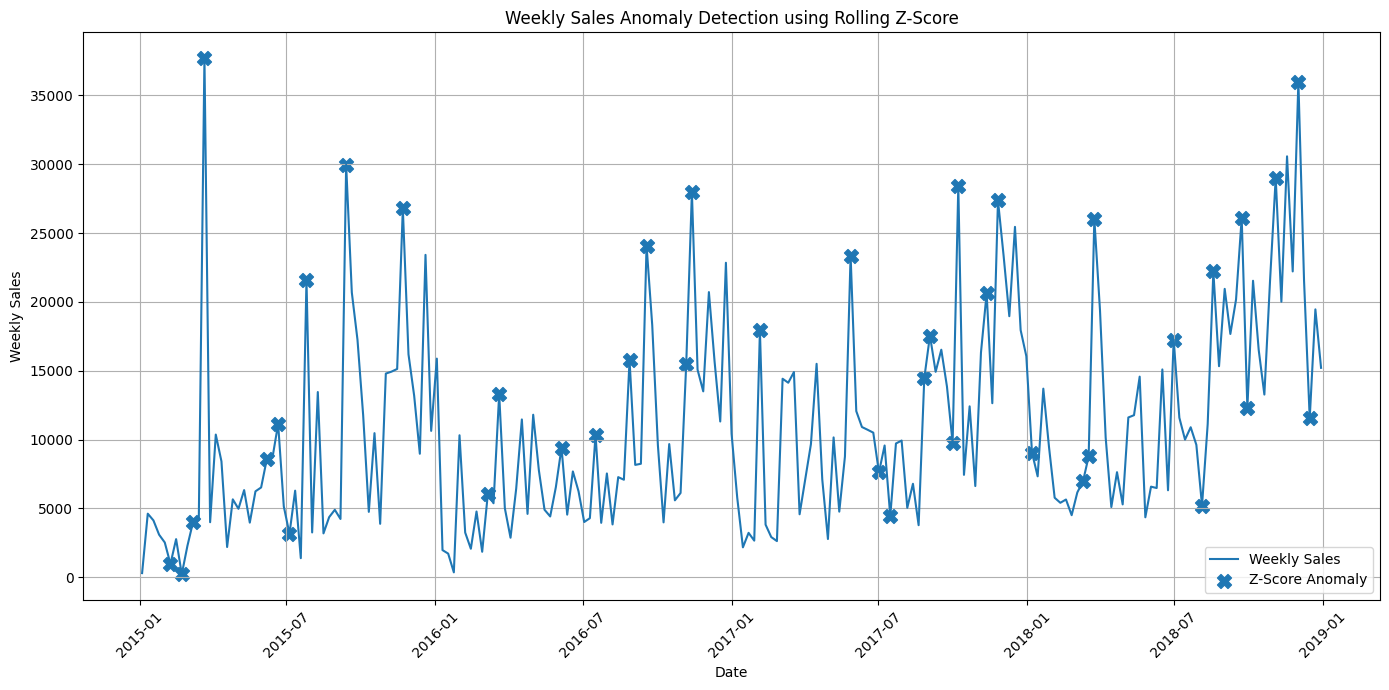

In [123]:
plt.figure(figsize=(14, 7))

plt.plot(
    weekly_df['Date'],
    weekly_df['Sales'],
    label='Weekly Sales'
)

plt.scatter(
    z_anomalies['Date'],
    z_anomalies['Sales'],
    label='Z-Score Anomaly',
    marker='X',
    s=100
)

plt.xlabel('Date')
plt.ylabel('Weekly Sales')

plt.title(
    'Weekly Sales Anomaly Detection using Rolling Z-Score'
)

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [124]:
iso_dates = set(
    iso_anomalies['Date']
)

z_dates = set(
    z_anomalies['Date']
)

common_dates = iso_dates.intersection(z_dates)

In [125]:
print(
    "Isolation Forest anomalies:",
    len(iso_dates)
)

print(
    "Z-score anomalies:",
    len(z_dates)
)

print(
    "Anomalies detected by both methods:",
    len(common_dates)
)

print(
    "\nCommon anomaly dates:"
)

for date in sorted(common_dates):
    print(date)

Isolation Forest anomalies: 11
Z-score anomalies: 40
Anomalies detected by both methods: 6

Common anomaly dates:
2015-02-08 00:00:00
2015-02-22 00:00:00
2015-03-22 00:00:00
2015-09-13 00:00:00
2018-11-04 00:00:00
2018-12-02 00:00:00


In [126]:
comparison_df = weekly_df[
    [
        'Date',
        'Sales',
        'Isolation_Anomaly',
        'Z_Anomaly'
    ]
].copy()


comparison_df['Isolation_Forest_Detected'] = (
    comparison_df['Isolation_Anomaly'] == -1
)


comparison_df['Detected_By_Both'] = (
    comparison_df['Isolation_Forest_Detected']
    & comparison_df['Z_Anomaly']
)


anomaly_comparison = comparison_df[
    comparison_df['Isolation_Forest_Detected']
    | comparison_df['Z_Anomaly']
].copy()


anomaly_comparison[
    [
        'Date',
        'Sales',
        'Isolation_Forest_Detected',
        'Z_Anomaly',
        'Detected_By_Both'
    ]
]

,Date,Sales,Isolation_Forest_Detected,Z_Anomaly,Detected_By_Both
0,2015-01-04,304.5080,True,False,False
5,2015-02-08,968.5340,True,True,True
7,2015-02-22,224.9120,True,True,True
9,2015-03-08,4030.7280,False,True,False
11,2015-03-22,37703.6650,True,True,True
22,2015-06-07,8569.9480,False,True,False
24,2015-06-21,11139.4446,False,True,False
26,2015-07-05,3158.4000,False,True,False
28,2015-07-19,1387.6860,True,False,False
29,2015-07-26,21590.0800,False,True,False


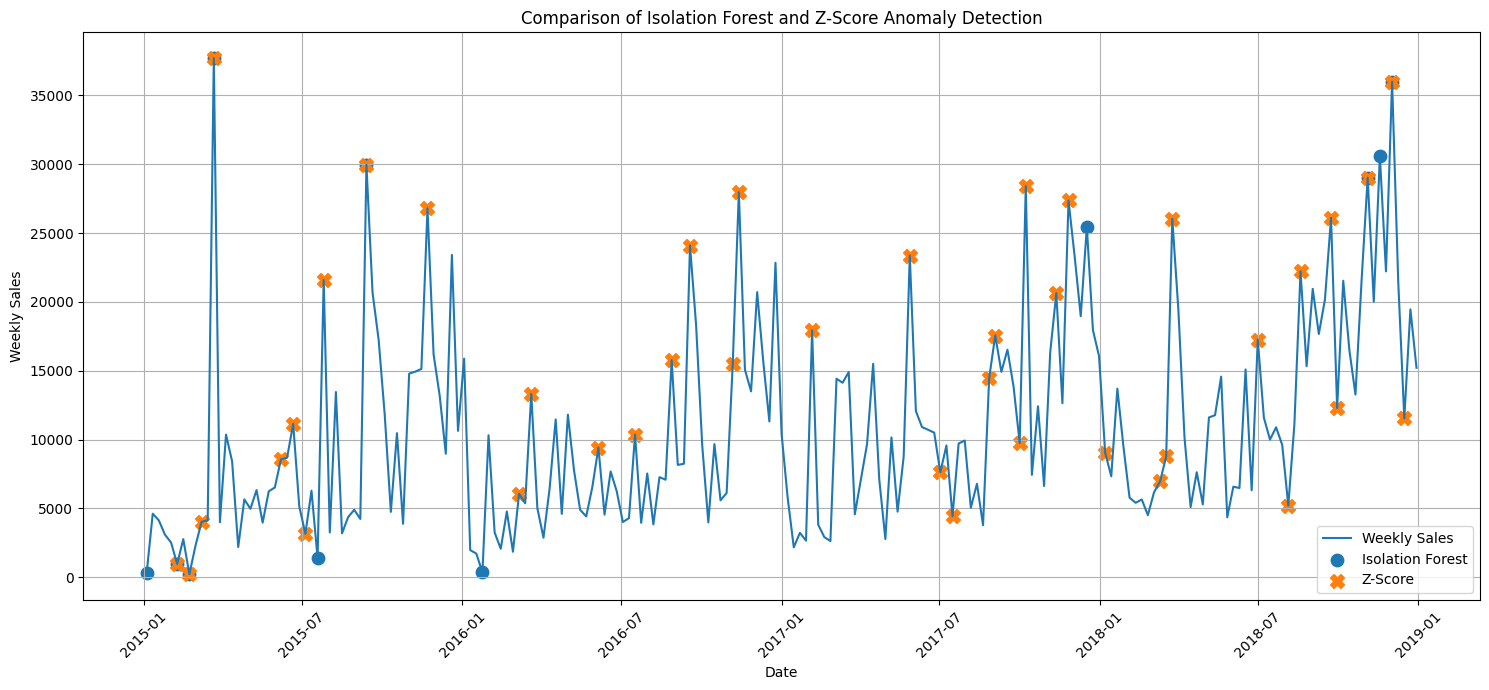

In [127]:
plt.figure(figsize=(15, 7))

# Original weekly sales
plt.plot(
    weekly_df['Date'],
    weekly_df['Sales'],
    label='Weekly Sales'
)


# Isolation Forest anomalies
plt.scatter(
    iso_anomalies['Date'],
    iso_anomalies['Sales'],
    marker='o',
    s=80,
    label='Isolation Forest'
)


# Z-score anomalies
plt.scatter(
    z_anomalies['Date'],
    z_anomalies['Sales'],
    marker='X',
    s=100,
    label='Z-Score'
)


plt.xlabel('Date')
plt.ylabel('Weekly Sales')

plt.title(
    'Comparison of Isolation Forest and Z-Score Anomaly Detection'
)

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# **Task 6 — Product Demand Segmentation using Clustering**

In [128]:
total_sales = (
    df_model
    .groupby('Sub-Category')['Sales']
    .sum()
    .rename('Total_Sales')
)

In [130]:
order_values = (
    df_model
    .groupby(['Sub-Category', 'Order ID'])['Sales']
    .sum()
    .reset_index()
)

avg_order_value = (
    order_values
    .groupby('Sub-Category')['Sales']
    .mean()
    .rename('Avg_Order_Value')
)

In [131]:
monthly_subcategory_sales = (
    df_model
    .groupby([
        'Sub-Category',
        pd.Grouper(key='Order Date', freq='ME')
    ])['Sales']
    .sum()
    .reset_index()
)

In [132]:
sales_volatility = (
    monthly_subcategory_sales
    .groupby('Sub-Category')['Sales']
    .std()
    .rename('Sales_Volatility')
)

In [133]:
yearly_subcategory_sales = (
    df_model
    .groupby([
        'Sub-Category',
        'Year'
    ])['Sales']
    .sum()
    .reset_index()
)

In [134]:
yearly_subcategory_sales['YoY_Growth'] = (
    yearly_subcategory_sales
    .groupby('Sub-Category')['Sales']
    .pct_change() * 100
)

In [135]:
avg_growth_rate = (
    yearly_subcategory_sales
    .groupby('Sub-Category')['YoY_Growth']
    .mean()
    .rename('Sales_Growth_Rate')
)

In [136]:
product_features = pd.concat(
    [
        total_sales,
        avg_growth_rate,
        sales_volatility,
        avg_order_value
    ],
    axis=1
).reset_index()

In [137]:
product_features

,Sub-Category,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Avg_Order_Value
0,Accessories,164186.7000,37.638071,2579.994809,233.884188
1,Appliances,104618.4030,39.927584,1821.621539,235.627034
2,Art,26705.4100,16.605553,330.488343,37.090847
3,Binders,200028.7850,21.873607,3848.223648,154.940964
4,Bookcases,113813.1987,23.806516,2220.405080,512.672066
5,Chairs,322822.7310,7.135790,4407.232960,570.358182
6,Copiers,146248.0940,84.671819,5500.774391,2215.880212
7,Envelopes,16128.0460,-2.766643,228.218688,66.370560
8,Fasteners,3001.9600,15.703383,48.742229,14.160189
9,Furnishings,89212.0180,28.788938,1360.017867,104.341542


In [138]:
product_features.isnull().sum()

,0
Sub-Category,0
Total_Sales,0
Sales_Growth_Rate,0
Sales_Volatility,0
Avg_Order_Value,0


In [139]:
from sklearn.preprocessing import StandardScaler

feature_columns = [
    'Total_Sales',
    'Sales_Growth_Rate',
    'Sales_Volatility',
    'Avg_Order_Value'
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    product_features[feature_columns]
)

In [140]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

k_values = range(1, 9)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

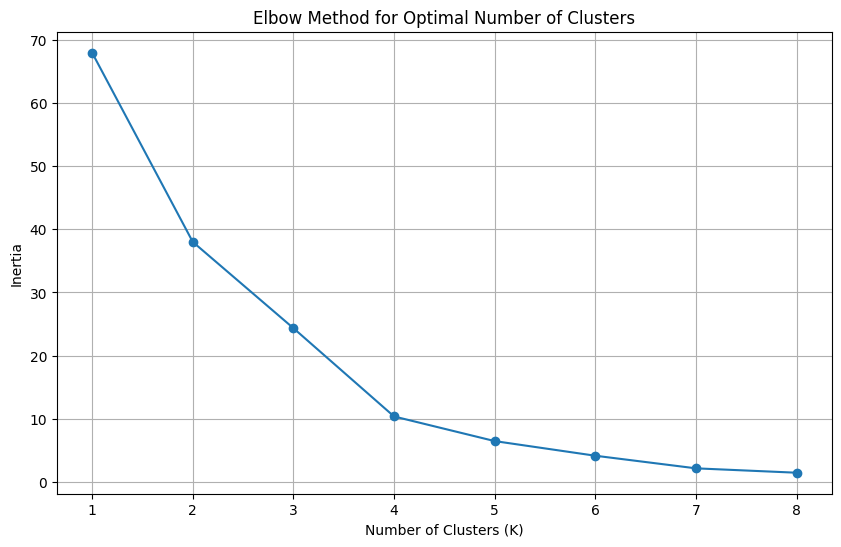

In [141]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')

plt.grid(True)

plt.show()

In [142]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

product_features['Cluster'] = kmeans.fit_predict(X_scaled)

In [143]:
product_features

,Sub-Category,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Avg_Order_Value,Cluster
0,Accessories,164186.7000,37.638071,2579.994809,233.884188,2
1,Appliances,104618.4030,39.927584,1821.621539,235.627034,1
2,Art,26705.4100,16.605553,330.488343,37.090847,1
3,Binders,200028.7850,21.873607,3848.223648,154.940964,2
4,Bookcases,113813.1987,23.806516,2220.405080,512.672066,1
5,Chairs,322822.7310,7.135790,4407.232960,570.358182,2
6,Copiers,146248.0940,84.671819,5500.774391,2215.880212,0
7,Envelopes,16128.0460,-2.766643,228.218688,66.370560,1
8,Fasteners,3001.9600,15.703383,48.742229,14.160189,1
9,Furnishings,89212.0180,28.788938,1360.017867,104.341542,1


In [144]:
cluster_summary = (
    product_features
    .groupby('Cluster')[feature_columns]
    .mean()
    .round(2)
)

cluster_summary

,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Avg_Order_Value
Cluster,,,,
0,167743.36,46.34,5552.16,1952.76
1,55331.88,19.96,907.22,134.08
2,239495.78,18.10,3489.06,387.67
3,46420.31,192.84,2025.09,256.47


In [156]:
cluster_labels = {
    0: 'High Value, High Volatility',
    1: 'Low Volume, Stable Demand',
    2: 'High Volume, Established Demand',
    3: 'Rapidly Growing Demand'
}

product_features['Demand_Segment'] = (
    product_features['Cluster'].map(cluster_labels)
)

In [146]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [147]:
product_features['PCA_1'] = X_pca[:, 0]
product_features['PCA_2'] = X_pca[:, 1]

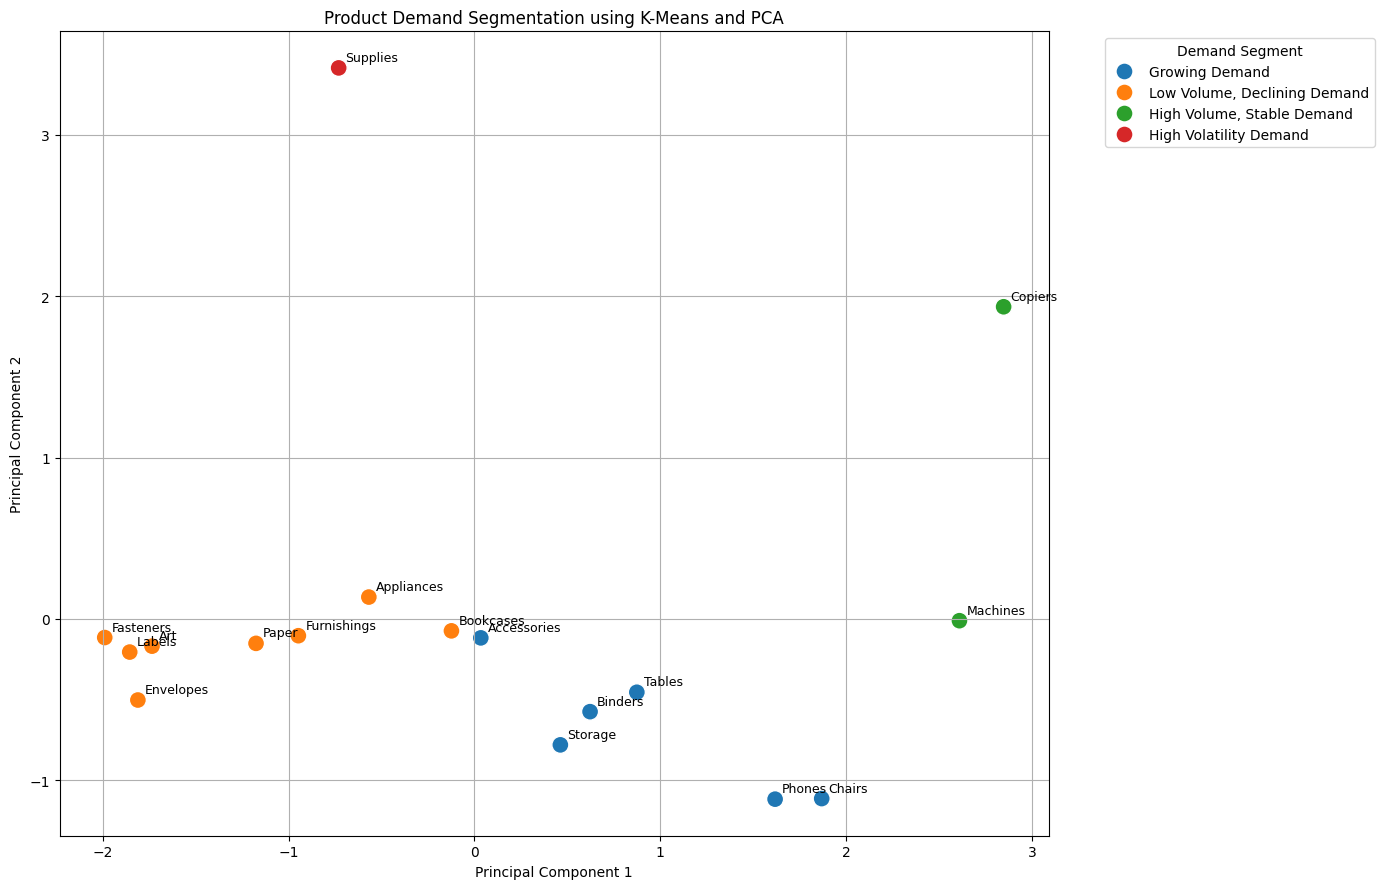

In [148]:
plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=product_features,
    x='PCA_1',
    y='PCA_2',
    hue='Demand_Segment',
    s=150
)

for _, row in product_features.iterrows():

    plt.annotate(
        row['Sub-Category'],
        (row['PCA_1'], row['PCA_2']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title(
    'Product Demand Segmentation using K-Means and PCA'
)

plt.legend(
    title='Demand Segment',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True)
plt.tight_layout()

plt.show()

In [158]:
segmentation_table = product_features[
    [
        'Sub-Category',
        'Total_Sales',
        'Sales_Growth_Rate',
        'Sales_Volatility',
        'Avg_Order_Value',
        'Cluster',
        'Demand_Segment'
    ]
].sort_values(
    by='Cluster'
)

segmentation_table

,Sub-Category,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Avg_Order_Value,Cluster,Demand_Segment
6,Copiers,146248.0940,84.671819,5500.774391,2215.880212,0,"High Value, High Volatility"
11,Machines,189238.6310,8.006001,5603.554747,1689.630634,0,"High Value, High Volatility"
4,Bookcases,113813.1987,23.806516,2220.405080,512.672066,1,"Low Volume, Stable Demand"
1,Appliances,104618.4030,39.927584,1821.621539,235.627034,1,"Low Volume, Stable Demand"
7,Envelopes,16128.0460,-2.766643,228.218688,66.370560,1,"Low Volume, Stable Demand"
9,Furnishings,89212.0180,28.788938,1360.017867,104.341542,1,"Low Volume, Stable Demand"
8,Fasteners,3001.9600,15.703383,48.742229,14.160189,1,"Low Volume, Stable Demand"
2,Art,26705.4100,16.605553,330.488343,37.090847,1,"Low Volume, Stable Demand"
12,Paper,76828.3040,25.413074,1024.824982,66.060451,1,"Low Volume, Stable Demand"
10,Labels,12347.7260,12.192651,223.471218,36.316841,1,"Low Volume, Stable Demand"


# **Write: what stocking strategy would you recommend for each cluster?**

In [159]:
stocking_strategies = {

    'High Value, High Volatility':
        'Maintain moderate safety stock and use frequent demand monitoring because sales are valuable but highly unpredictable.',

    'Low Volume, Stable Demand':
        'Maintain lean inventory with regular replenishment because demand is stable but overall sales volume is relatively low.',

    'High Volume, Established Demand':
        'Maintain consistently high inventory levels and reliable replenishment cycles to prevent stockouts in this high-volume segment.',

    'Rapidly Growing Demand':
        'Gradually increase inventory levels and monitor growth frequently to capture rising demand while avoiding excessive overstocking.'
}

product_features['Stocking_Strategy'] = (
    product_features['Demand_Segment']
    .map(stocking_strategies)
)

In [160]:
product_features['Stocking_Strategy'] = (
    product_features['Demand_Segment'].map(stocking_strategies)
)

product_features[
    [
        'Sub-Category',
        'Demand_Segment',
        'Stocking_Strategy'
    ]
]

,Sub-Category,Demand_Segment,Stocking_Strategy
0,Accessories,"High Volume, Established Demand",Maintain consistently high inventory levels an...
1,Appliances,"Low Volume, Stable Demand",Maintain lean inventory with regular replenish...
2,Art,"Low Volume, Stable Demand",Maintain lean inventory with regular replenish...
3,Binders,"High Volume, Established Demand",Maintain consistently high inventory levels an...
4,Bookcases,"Low Volume, Stable Demand",Maintain lean inventory with regular replenish...
5,Chairs,"High Volume, Established Demand",Maintain consistently high inventory levels an...
6,Copiers,"High Value, High Volatility",Maintain moderate safety stock and use frequen...
7,Envelopes,"Low Volume, Stable Demand",Maintain lean inventory with regular replenish...
8,Fasteners,"Low Volume, Stable Demand",Maintain lean inventory with regular replenish...
9,Furnishings,"Low Volume, Stable Demand",Maintain lean inventory with regular replenish...


In [161]:
cluster_summary

,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Avg_Order_Value
Cluster,,,,
0,167743.36,46.34,5552.16,1952.76
1,55331.88,19.96,907.22,134.08
2,239495.78,18.10,3489.06,387.67
3,46420.31,192.84,2025.09,256.47




The Elbow Method identified four as an appropriate number of clusters. K-Means segmentation revealed four distinct product demand groups. Cluster 2 represents the highest-volume products, with average total sales of approximately 239,496, making these products important candidates for consistent inventory availability. Cluster 0 contains high-value products with the highest average order value of approximately 1,953 but also the greatest sales volatility, requiring careful safety-stock management. Cluster 1 represents relatively low-volume but stable-demand products, suitable for lean inventory strategies. Cluster 3 shows the strongest growth, with an average year-over-year growth rate of approximately 192.84%, suggesting emerging products whose inventory levels may need to be gradually increased.

In [162]:
product_features[
    [
        'Sub-Category',
        'Cluster',
        'Demand_Segment',
        'Total_Sales',
        'Sales_Growth_Rate',
        'Sales_Volatility',
        'Avg_Order_Value'
    ]
].sort_values('Cluster')

,Sub-Category,Cluster,Demand_Segment,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Avg_Order_Value
6,Copiers,0,"High Value, High Volatility",146248.0940,84.671819,5500.774391,2215.880212
11,Machines,0,"High Value, High Volatility",189238.6310,8.006001,5603.554747,1689.630634
4,Bookcases,1,"Low Volume, Stable Demand",113813.1987,23.806516,2220.405080,512.672066
1,Appliances,1,"Low Volume, Stable Demand",104618.4030,39.927584,1821.621539,235.627034
7,Envelopes,1,"Low Volume, Stable Demand",16128.0460,-2.766643,228.218688,66.370560
9,Furnishings,1,"Low Volume, Stable Demand",89212.0180,28.788938,1360.017867,104.341542
8,Fasteners,1,"Low Volume, Stable Demand",3001.9600,15.703383,48.742229,14.160189
2,Art,1,"Low Volume, Stable Demand",26705.4100,16.605553,330.488343,37.090847
12,Paper,1,"Low Volume, Stable Demand",76828.3040,25.413074,1024.824982,66.060451
10,Labels,1,"Low Volume, Stable Demand",12347.7260,12.192651,223.471218,36.316841


**# Task 7 — Interactive Streamlit Dashboard**

An interactive multi-page Streamlit dashboard was developed to present the major results of this project in a business-friendly format. The dashboard includes:

- Sales Overview Dashboard
- Forecast Explorer
- Anomaly Report
- Product Demand Segments

The application allows users to explore historical sales, generate forecasts, examine anomalous sales periods, and review product demand segments interactively.

Live Streamlit App:

**# Task 8 — Executive Business Report**

A structured two-page executive business report has been prepared for the Head of Supply Chain and CFO. The report summarizes the major findings from sales analysis, forecasting, anomaly detection, and product demand segmentation, along with actionable business recommendations.

The report is included separately as `summary.pdf`.